In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset downloaded from Kaggle
df = pd.read_csv('housing.csv')
print("--- Dataset Rows and Columns ---")
print(df.shape)

# 2. Check for missing values
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# 3. Handle missing values (total_bedrooms has some missing fields, let's fill them with the median)
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# 4. Drop the text column 'ocean_proximity' for simplicity so our model can read it easily
df = df.drop(columns=['ocean_proximity'])

print("\n--- Cleaned Data Sample ---")
print(df.head())


--- Dataset Rows and Columns ---
(20640, 10)

--- Missing Values Check ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

--- Cleaned Data Sample ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  
0       322.0       126.0         8.3252            452600.0  
1      2401.0      1138.0         8.3014      

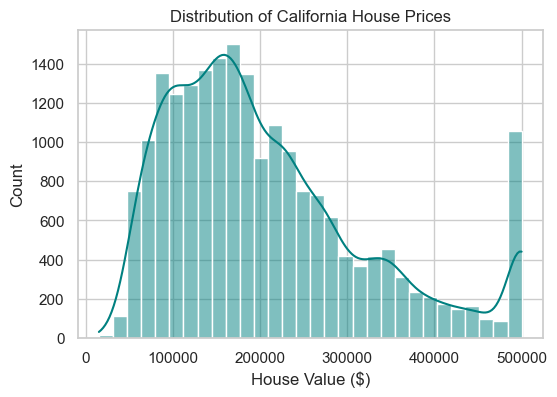

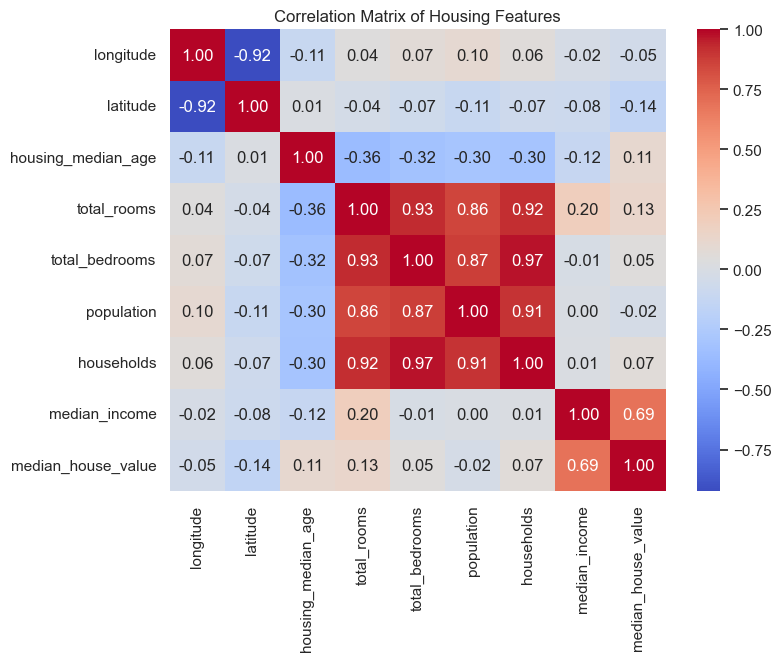

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Distribution Chart of the Target Variable (Median House Value)
plt.figure(figsize=(6, 4))
sns.histplot(df['median_house_value'], kde=True, color='teal', bins=30)
plt.title('Distribution of California House Prices')
plt.xlabel('House Value ($)')
plt.ylabel('Count')
plt.savefig('price_distribution.png') # Automatically saves for your checklist
plt.show()

# 2. Heatmap to show feature correlations
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Housing Features')
plt.savefig('correlation_matrix.png') # Automatically saves for your checklist
plt.show()

--- Model Performance ---
Mean Squared Error (MSE): 5059928371.17
R-squared (R2) Score: 0.6139


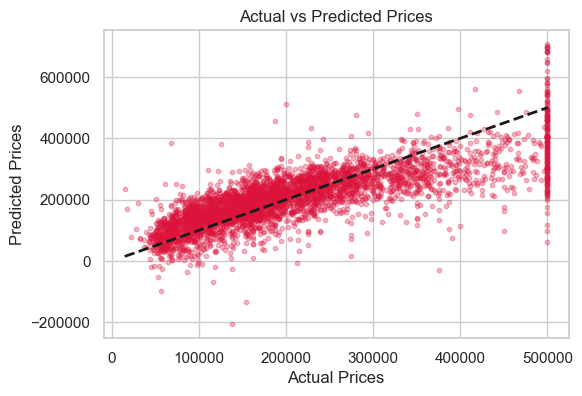

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Separate features (X) and the price target (y)
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

# 2. Split data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict prices for our testing data
y_pred = model.predict(X_test)

# 5. Evaluate results
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}") 

# Plot Actual values vs Predicted values
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='crimson', alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.savefig('actual_vs_predicted.png')
plt.show()
